# Clarity Bookings Dataset Analysis

Objective:
Analyze airline booking patterns for 2025 and provide business insights regarding:

- Revenue performance
- Cancellation behaviour
- Booking trends
- Customer behaviour
- Data quality

In [3]:
! pip install pandas numpy matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------- ----------- 6.0/8.3 MB 29.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 29.1 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 35.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 40.3 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]
   -------------

In [70]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("------installed-------")

------installed-------


### Load Dataset

In [11]:
df = pd.read_csv(r"C:\Users\ms900\OneDrive\Desktop\Tasks\Data_Science_task\clarity_bookings_dataset.csv")
df.head()

,booking_id,booking_date,departure_date,lead_time_days,airline,origin,destination,haul_type,cabin_class,trip_type,...,pax_count,base_fare_inr,taxes_inr,total_fare_inr,ancillary_revenue_inr,payment_method,prior_bookings,booking_status,customer_complaint,satisfaction_score
0,CLR-00001,2025-11-24,2025-12-09,15,Air Canada,DEL,LHR,Long-Haul,Economy,Round-Trip,...,2,18788.67,1749.55,41076.44,NaN,Credit Card,0,Ticketed,NaN,5.0
1,CLR-00002,2025-06-24,2025-07-30,36,Condor,BLR,FRA,Long-Haul,First,One-Way,...,3,286719.58,52229.54,1016847.36,9372.39,Agent Credit,0,Cancelled,NaN,NaN
2,CLR-00003,2025-05-29,2025-06-09,11,KLM,DEL,JFK,Long-Haul,Economy,One-Way,...,1,43848.08,7703.96,51552.04,0.00,Credit Card,0,Ticketed,NaN,5.0
3,CLR-00004,2025-04-28,2025-08-12,106,American Airlines,BOM,DXB,Medium-Haul,Economy,Round-Trip,...,3,19142.46,2591.67,65202.39,6750.15,Credit Card,0,Ticketed,NaN,5.0
4,CLR-00005,2025-01-25,2025-05-16,111,Etihad Airways,DEL,CDG,Long-Haul,Premium Economy,One-Way,...,1,67299.98,14533.50,81833.48,0.00,Credit Card,1,Ticketed,NaN,4.0


In [78]:

print("------Shape------")
df.shape


------Shape------


(2000, 28)

In [80]:
print("-----Infomation-----")
df.info()
print("------describe-main------")
df.describe()

-----Infomation-----
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   booking_id             2000 non-null   str           
 1   booking_date           2000 non-null   datetime64[us]
 2   departure_date         2000 non-null   datetime64[us]
 3   lead_time_days         2000 non-null   int64         
 4   airline                2000 non-null   str           
 5   origin                 2000 non-null   str           
 6   destination            2000 non-null   str           
 7   haul_type              2000 non-null   str           
 8   cabin_class            2000 non-null   str           
 9   trip_type              2000 non-null   str           
 10  fare_basis             2000 non-null   str           
 11  booking_channel        2000 non-null   str           
 12  booking_source         2000 non-null   str          

,booking_date,departure_date,lead_time_days,pax_count,base_fare_inr,taxes_inr,total_fare_inr,ancillary_revenue_inr,prior_bookings,satisfaction_score,booking_quarter
count,2000,2000,2000.000000,2000.00000,2000.00000,2000.000000,2.000000e+03,2000.000000,2000.000000,1737.000000,2000.000000
mean,2025-06-30 03:54:00,2025-08-30 10:34:19.200000,61.278000,2.08700,52354.05989,7898.540460,1.253193e+05,3224.401410,3.790000,3.681059,2.493500
min,2025-01-01 00:00:00,2025-01-07 00:00:00,1.000000,1.00000,8084.06000,768.030000,8.911110e+03,0.000000,0.000000,1.000000,1.000000
25%,2025-03-31 00:00:00,2025-06-01 00:00:00,31.000000,1.00000,22122.60250,3219.677500,4.235889e+04,0.000000,0.000000,3.000000,1.000000
50%,2025-06-27 00:00:00,2025-08-29 00:00:00,62.000000,2.00000,36681.45000,5273.425000,7.803476e+04,1400.840000,0.000000,4.000000,2.000000
75%,2025-10-01 06:00:00,2025-11-28 06:00:00,91.000000,3.00000,62549.99250,9306.990000,1.476526e+05,4186.942500,6.000000,5.000000,4.000000
max,2025-12-31 00:00:00,2026-04-26 00:00:00,120.000000,6.00000,328167.32000,67222.850000,1.729676e+06,40214.880000,20.000000,5.000000,4.000000
std,NaN,NaN,34.401155,1.19505,47830.89132,7920.876238,1.537680e+05,4847.870447,6.224409,1.117855,1.121868


### Check Missing Values

In [14]:
missing = df.isnull().sum()
print(missing)

booking_id                  0
booking_date                0
departure_date              0
lead_time_days              0
airline                     0
origin                      0
destination                 0
haul_type                   0
cabin_class                 0
trip_type                   0
fare_basis                 41
booking_channel             0
booking_source              0
pax_count                   0
base_fare_inr               0
taxes_inr                   0
total_fare_inr              0
ancillary_revenue_inr      55
payment_method            104
prior_bookings              0
booking_status              0
customer_complaint       1752
satisfaction_score        263
dtype: int64


In [16]:
#missing values 
missing[missing > 0].sort_values(ascending=False)

customer_complaint       1752
satisfaction_score        263
payment_method            104
ancillary_revenue_inr      55
fare_basis                 41
dtype: int64

### Handle Missing Values

In [22]:
#fare_basis
df['fare_basis'] = df['fare_basis'].fillna('Unknown')
#ancillary_revenue_inr
df['ancillary_revenue_inr'] = df['ancillary_revenue_inr'].fillna(0)
#payment_method
df['payment_method'] = df['payment_method'].fillna('Unknown')
#satisfaction_score
#Missing satisfaction ratings were excluded from satisfaction analysis.
df['satisfaction_score'].isnull().mean()*100

np.float64(13.15)

In [24]:
#customer_complaint
df['customer_complaint'] = df['customer_complaint'].fillna('No Complaint')

### Convert Dates

In [23]:
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['departure_date'] = pd.to_datetime(df['departure_date'])

In [25]:
df['booking_month'] = df['booking_date'].dt.month_name()

df['booking_quarter'] = df['booking_date'].dt.quarter

## PART 1: Revenue Analysis

### Airline Revenue

#### Top revenue-generating airlines


In [27]:
airline_revenue = (
    df.groupby('airline')['total_fare_inr']
    .sum()
    .sort_values(ascending=False)
)
print(airline_revenue)

airline
Air France            31079226.75
KLM                   27917987.49
Etihad Airways        27422622.62
Emirates              26363325.88
Condor                25853898.11
Lufthansa             25233232.02
Singapore Airlines    22440269.59
Air Canada            21903023.38
British Airways       21458250.92
American Airlines     20966839.46
Name: total_fare_inr, dtype: float64


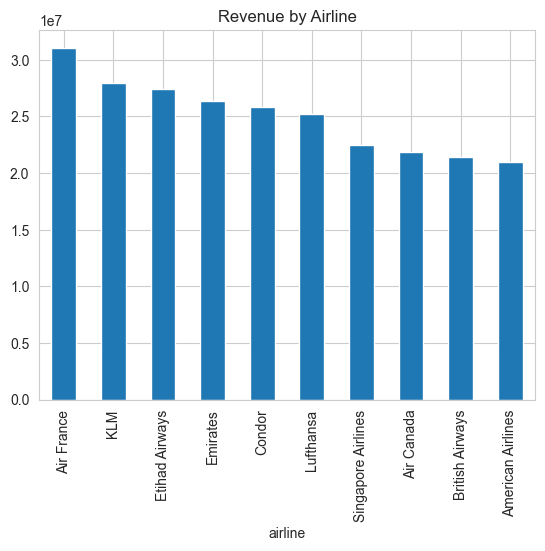

In [29]:
#Airline Revenue Visualization
airline_revenue.plot(kind='bar')
plt.title("Revenue by Airline")
plt.show()

In [31]:
df.head()

,booking_id,booking_date,departure_date,lead_time_days,airline,origin,destination,haul_type,cabin_class,trip_type,...,total_fare_inr,ancillary_revenue_inr,payment_method,prior_bookings,booking_status,customer_complaint,satisfaction_score,booking_month,booking_quarter,route
0,CLR-00001,2025-11-24,2025-12-09,15,Air Canada,DEL,LHR,Long-Haul,Economy,Round-Trip,...,41076.44,0.00,Credit Card,0,Ticketed,No Complaint,5.0,November,4,DEL-LHR
1,CLR-00002,2025-06-24,2025-07-30,36,Condor,BLR,FRA,Long-Haul,First,One-Way,...,1016847.36,9372.39,Agent Credit,0,Cancelled,No Complaint,NaN,June,2,BLR-FRA
2,CLR-00003,2025-05-29,2025-06-09,11,KLM,DEL,JFK,Long-Haul,Economy,One-Way,...,51552.04,0.00,Credit Card,0,Ticketed,No Complaint,5.0,May,2,DEL-JFK
3,CLR-00004,2025-04-28,2025-08-12,106,American Airlines,BOM,DXB,Medium-Haul,Economy,Round-Trip,...,65202.39,6750.15,Credit Card,0,Ticketed,No Complaint,5.0,April,2,BOM-DXB
4,CLR-00005,2025-01-25,2025-05-16,111,Etihad Airways,DEL,CDG,Long-Haul,Premium Economy,One-Way,...,81833.48,0.00,Credit Card,1,Ticketed,No Complaint,4.0,January,1,DEL-CDG


### Route Revenue

In [32]:
df['route'] = df['origin'] + "-" + df['destination']
route_revenue = (
    df.groupby('route')['total_fare_inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

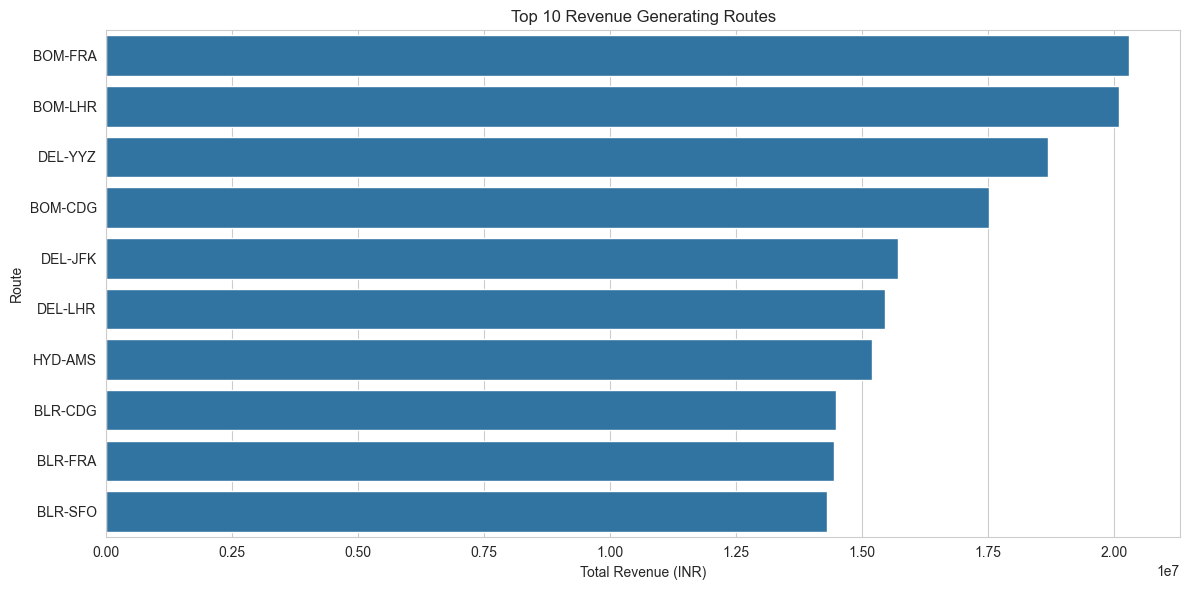

In [36]:
# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=route_revenue.values,
    y=route_revenue.index,
)

plt.title('Top 10 Revenue Generating Routes')
plt.xlabel('Total Revenue (INR)')
plt.ylabel('Route')

plt.tight_layout()
plt.show()

### Cabin Revenue

In [33]:
cabin_revenue = (
    df.groupby('cabin_class')['total_fare_inr']
    .sum()
    .sort_values(ascending=False)
)

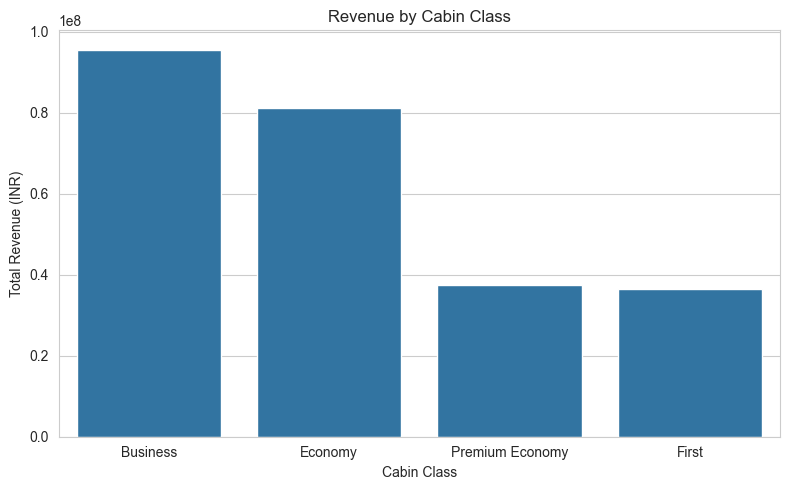

In [37]:
# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    x=cabin_revenue.index,
    y=cabin_revenue.values
)

plt.title('Revenue by Cabin Class')
plt.xlabel('Cabin Class')
plt.ylabel('Total Revenue (INR)')

plt.tight_layout()
plt.show()

### Revenue by Booking Source

<Axes: >

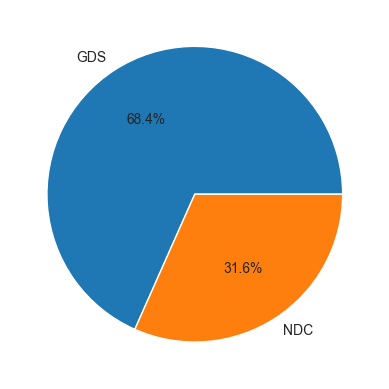

In [35]:
source_revenue = (
    df.groupby('booking_source')['total_fare_inr']
    .sum()
)
source_revenue.plot(kind='pie', autopct='%1.1f%%')

## PART 2: Cancellation Analysis

#### Overall cancellation rate

In [38]:
cancel_status = [
    'Cancelled',
    'Refunded',
    'No-Show'
]

df['is_cancelled'] = df['booking_status'].isin(cancel_status)

In [41]:
cancellation_rate = (
    df['is_cancelled'].mean()*100
)
print("Cancellation rate :",cancellation_rate)

Cancellation rate : 25.1


### Lead Time vs Cancellation

<Axes: xlabel='is_cancelled', ylabel='lead_time_days'>

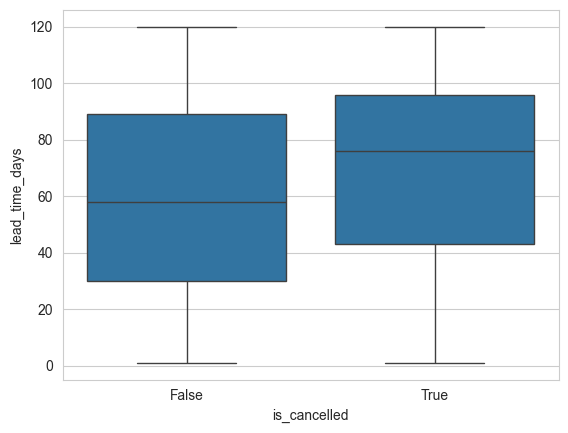

In [42]:
sns.boxplot(
    x='is_cancelled',
    y='lead_time_days',
    data=df
)

### Fare vs Cancellation

<Axes: xlabel='is_cancelled', ylabel='total_fare_inr'>

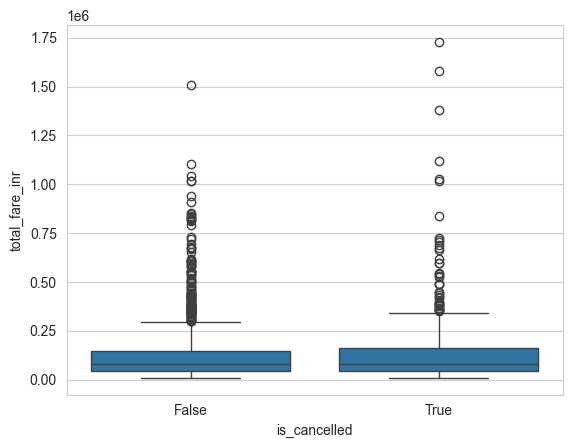

In [43]:
sns.boxplot(
    x='is_cancelled',
    y='total_fare_inr',
    data=df
)

### Cancellation by Channel

In [44]:
cancel_channel = pd.crosstab(
    df['booking_channel'],
    df['is_cancelled'],
    normalize='index'
)*100

<Axes: xlabel='is_cancelled', ylabel='booking_channel'>

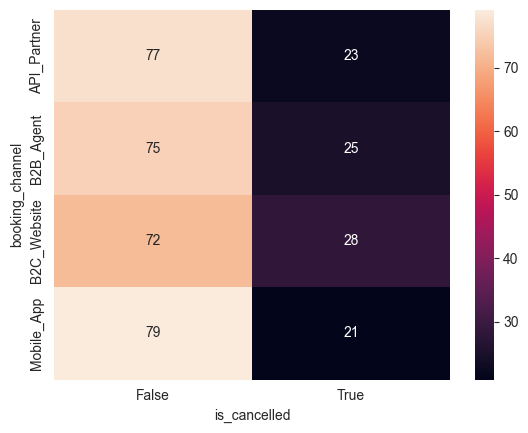

In [46]:
# Heatmap:
sns.heatmap(cancel_channel, annot=True)

## PART 3: Booking Trends

### Monthly Bookings

In [47]:
monthly_bookings = (
    df.groupby(df['booking_date'].dt.month)
    .size()
)

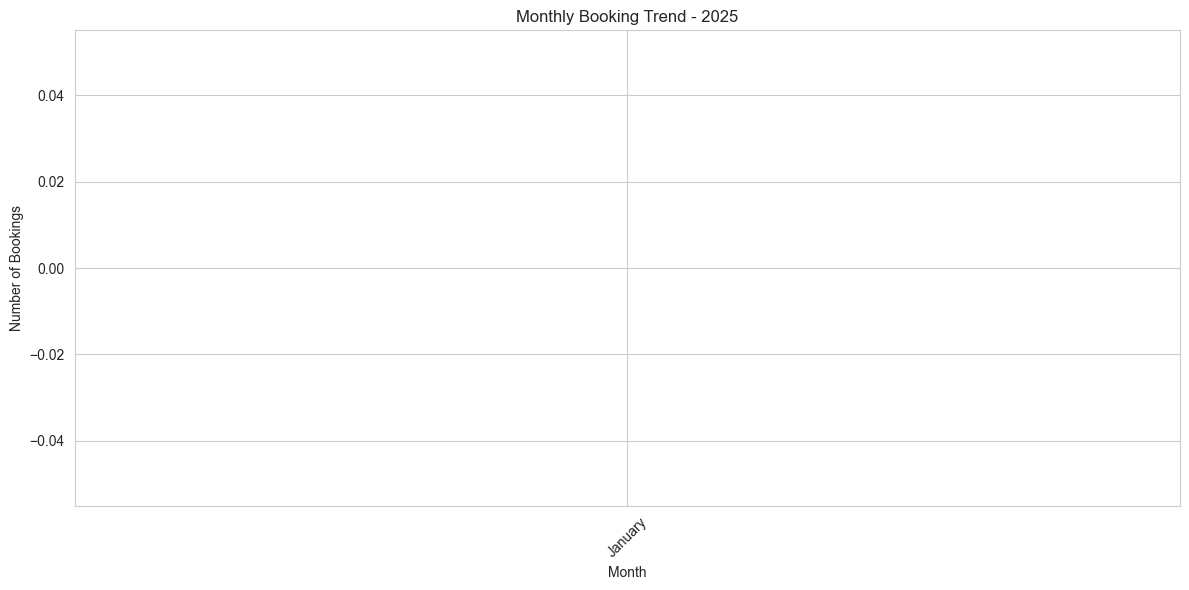

In [54]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_bookings = monthly_bookings.reindex(month_order)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_bookings.index,
    y=monthly_bookings.values,
    marker='o'
)

plt.title('Monthly Booking Trend - 2025')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Monthly Revenue Trend

In [49]:
monthly_revenue = (
    df.groupby(df['booking_date'].dt.month)['total_fare_inr']
    .sum()
)

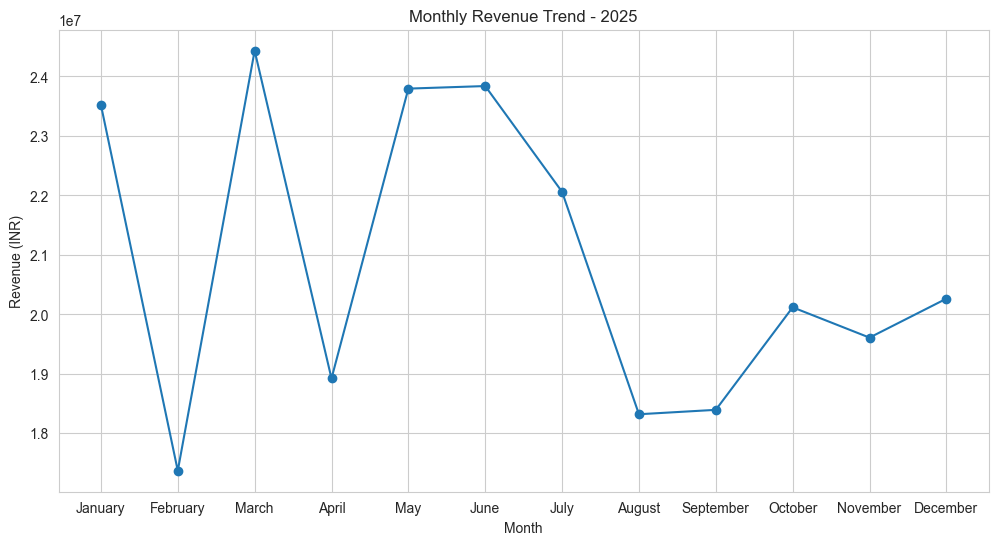

In [56]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker='o'
)

plt.xticks(range(1,13), month_order)

plt.title('Monthly Revenue Trend - 2025')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')

plt.grid(True)

plt.show()

### Channel Mix by Month

In [57]:
channel_month = pd.crosstab(
    df['booking_month'],
    df['booking_channel']
)

<Axes: xlabel='booking_month'>

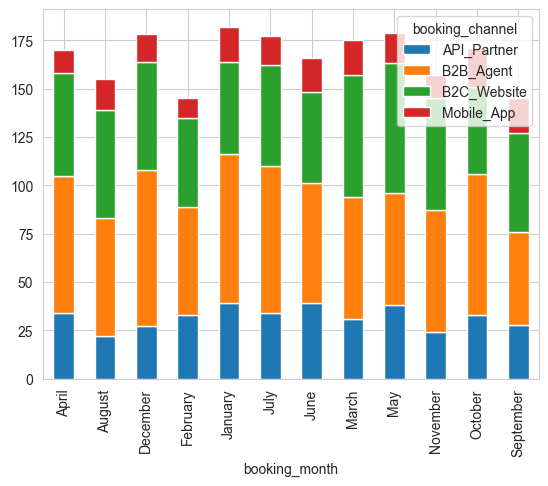

In [59]:
channel_month.plot(
    kind='bar',
    stacked=True
)

## PART 4: Customer Behaviour

#### Customer Type

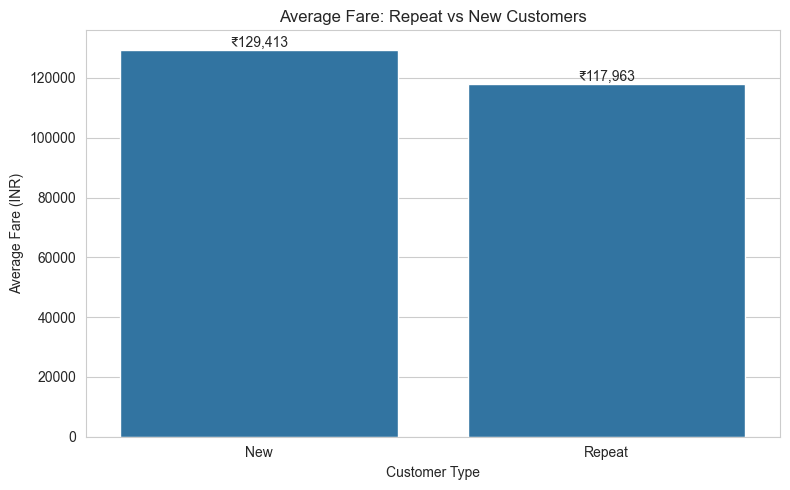

In [62]:
# Average fare by customer type
avg_fare = (
    df.groupby('customer_type')['total_fare_inr']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=avg_fare.index,
    y=avg_fare.values
)

# Add values on top of bars
for i, value in enumerate(avg_fare.values):
    ax.text(
        i,
        value,
        f'₹{value:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title('Average Fare: Repeat vs New Customers')
plt.xlabel('Customer Type')
plt.ylabel('Average Fare (INR)')

plt.tight_layout()
plt.show()

### 1. Cancellation Rate by Customer Type

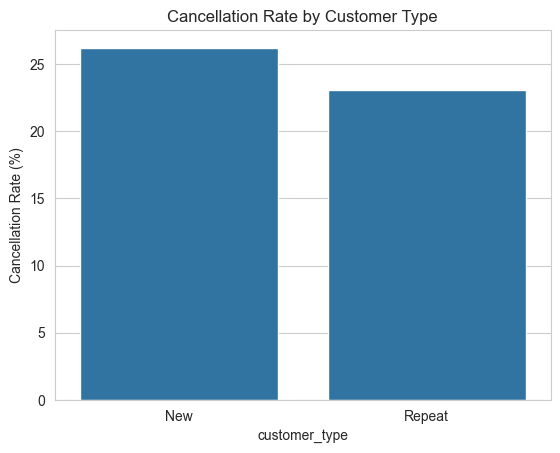

In [63]:
cancel_rate = (
    df.groupby('customer_type')['is_cancelled']
    .mean() * 100
)

sns.barplot(
    x=cancel_rate.index,
    y=cancel_rate.values
)

plt.title('Cancellation Rate by Customer Type')
plt.ylabel('Cancellation Rate (%)')
plt.show()

### 2. Satisfaction Score by Customer Type

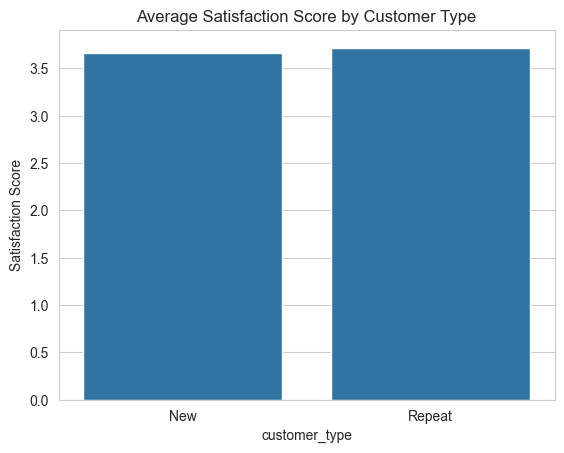

In [64]:
satisfaction = (
    df.groupby('customer_type')['satisfaction_score']
    .mean()
)

sns.barplot(
    x=satisfaction.index,
    y=satisfaction.values
)

plt.title('Average Satisfaction Score by Customer Type')
plt.ylabel('Satisfaction Score')
plt.show()

## Revenue by Cabin and Source

In [65]:
pivot = pd.pivot_table(
    df,
    values='total_fare_inr',
    index='cabin_class',
    columns='booking_source',
    aggfunc='sum'
)

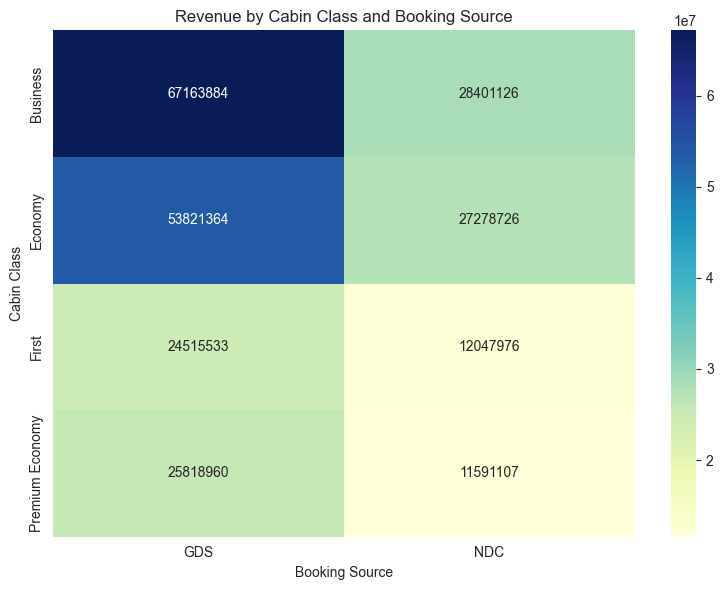

In [66]:
plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Revenue by Cabin Class and Booking Source')
plt.xlabel('Booking Source')
plt.ylabel('Cabin Class')

plt.tight_layout()
plt.show()

### 2. Correlation Analysis Heatmap

In [68]:
numeric_cols = [
    'lead_time_days',
    'pax_count',
    'base_fare_inr',
    'taxes_inr',
    'total_fare_inr',
    'prior_bookings',
    'satisfaction_score'
]

corr = df[numeric_cols].corr()

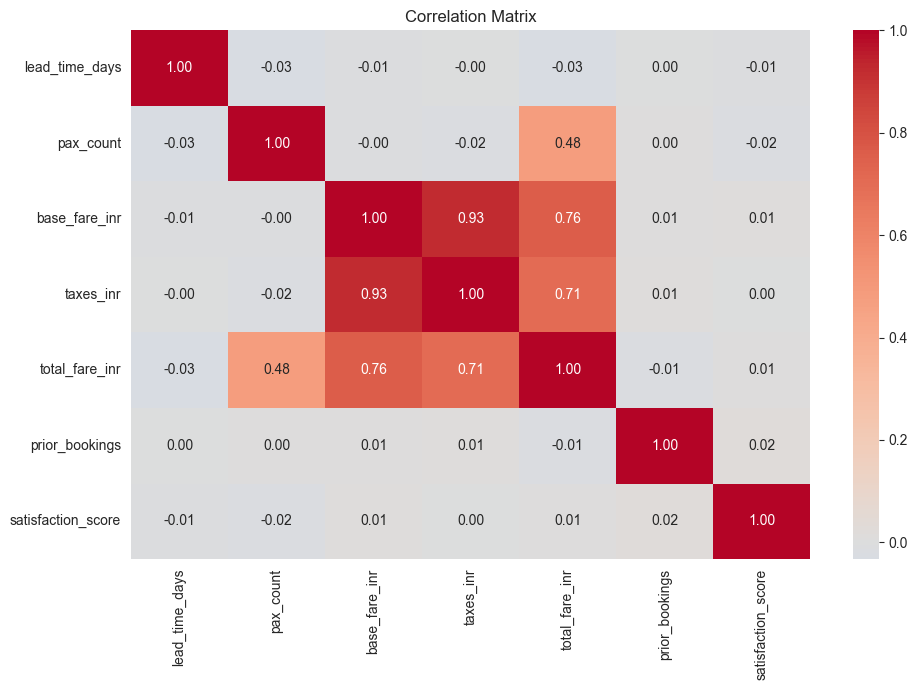

In [69]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()